омашняя Работа 3. Онищенко Геннадий 336883.

Труднее всего было задание про боксплот, но вроде разобрался

Буду рад обратной связи, спасибо!

# 1. Считать датасет из файла train.csv (это данные о выживаемости на Титанике)

Сначла импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Как в предыдущей домашке считываем файл

In [2]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/train.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. Визуализировать распределение значений признаков Survived, Pclass, Age, Sex, Parch.

1. Визуализация Survived.

Строим столбчатую диаграмму распределения выживаемости `df.Survived.value_counts()` считает количество пассажиров с `Survived=0` и `Survived=1` , `sns.barplot(x=data.index, y=data.values)` рисует два столбика где по оси X значения 0 и 1, а по Y их количество, далее `plt.title('Класс')` добавляет заголовок, plt.ylabel('Количество, чел.') подписывает ось Y.

Text(0.5, 0, 'Выжил (1)    Погиб (0)')

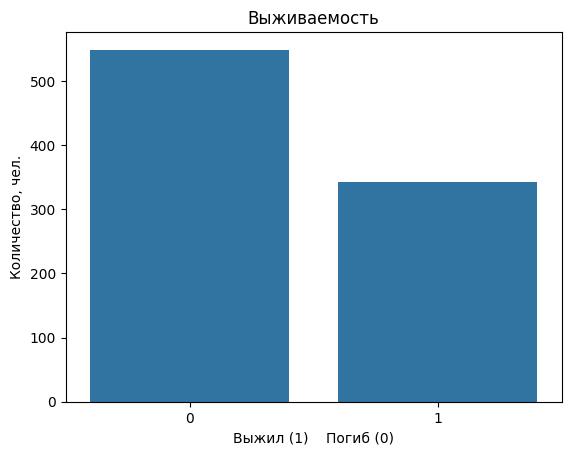

In [4]:
data = df.Survived.value_counts()
sns.barplot(x=data.index, y=data.values)
plt.title('Выживаемость')
plt.ylabel('Количество, чел.')
plt.xlabel('Выжил (1)    Погиб (0)')


2. Визуализация Pclass.


Строим столбчатую диаграмму распределения пассажиров по классам Титаника `df.Pclass.value_counts()` считает количество людей в каждом классе, s`ns.barplot(x=data.index, y=data.values)` рисует три столбика где по оси X номера классов (1,2,3), а по Y количество пассажиров, `plt.title('Распределение по классам') `задает заголовок, plt.ylabel`('Количество, чел.')` подписывает ось Y.

Text(0, 0.5, 'Количество, чел.')

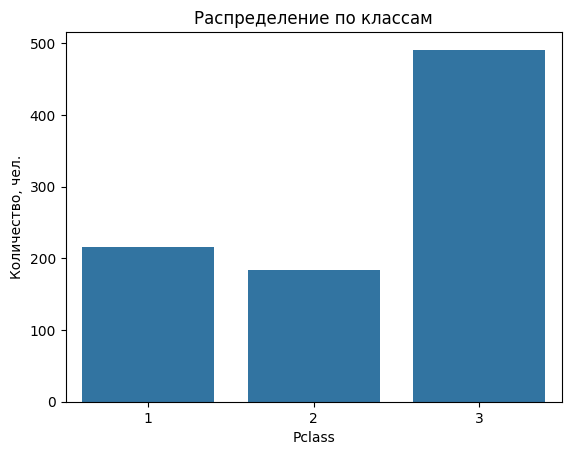

In [5]:
data = df.Pclass.value_counts()
sns.barplot(x=data.index, y=data.values)
plt.title('Распределение по классам')
plt.ylabel('Количество, чел.')

3. Визуализация Age.


Строим столбчатую диаграмму распределения пассажиров по возростам. `df.dropna(subset=['Age'])`, затем `df['Age'].value_counts().sort_index()` считает количество людей каждого возраста от 0 до 80 лет и сортирует по возрастанию, `plt.figure(figsize=(20, 6))` создает широкий холст, `sns.barplot() `рисует столбцы с цветовой палитрой инферно где по оси X все возрастные значения, а по Y количество пассажиров, `plt.xticks(rotation=90)` поворачивает подписи возрастов вертикально для читаемости.

/tmp/ipykernel_38526/215085321.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values, palette='inferno')


Text(0, 0.5, 'Количество, чел.')

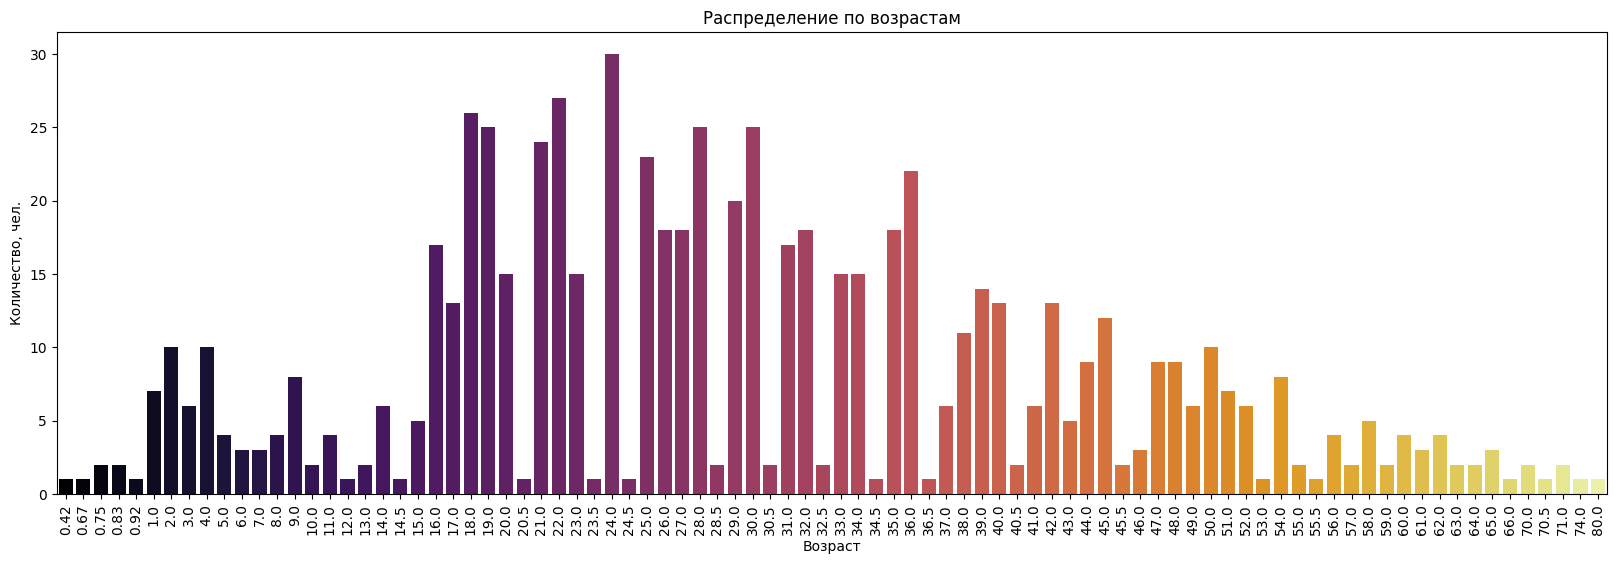

In [6]:
df = df.dropna(subset=['Age'])
age_counts = df['Age'].value_counts().sort_index()

plt.figure(figsize=(20, 6))
sns.barplot(x=age_counts.index, y=age_counts.values, palette='inferno')
plt.xticks(rotation=90)
plt.title('Распределение по возрастам')
plt.xlabel('Возраст')
plt.ylabel('Количество, чел.')



4. Визуализация Sex.


Строим столбчатую диаграмму распределения пассажиров Титаника по полу `df.Sex.value_counts()` считает мужчин и женщин, `sns.barplot()` рисует два столбика с синим цветом для мужчин и розовым для женщин через словарь `palette={'male': 'blue', 'female': 'pink'}`, `plt.yticks(range(0, data.max() + 100, 50))` ставит деления на оси Y с шагом 50 до максимального значения

/tmp/ipykernel_38526/1496636254.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values,


Text(0, 0.5, 'Количество, чел.')

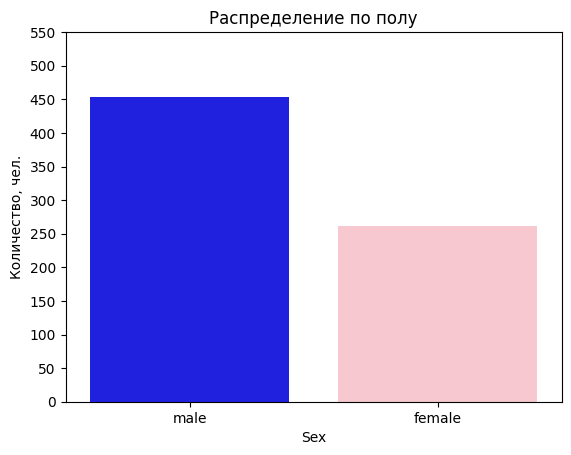

In [7]:
data = df.Sex.value_counts()
sns.barplot(x=data.index, y=data.values,
            palette={'male': 'blue', 'female': 'pink'})
plt.yticks(range(0, data.max() + 100, 50))
plt.title('Распределение по полу')
plt.ylabel('Количество, чел.')

5. Визуализация Parch.

Здесь я решил визуализировать людей с родственниками и без них, как в предыдущей домашке. `df['has_relatives'] = (df['Parch'] > 0) | (df['SibSp'] > 0)` создает новый столбец "есть родственники", где True = есть родственники, False = одиночка.

/tmp/ipykernel_38526/909134613.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=relatives_counts.index, y=relatives_counts.values,


([<matplotlib.axis.XTick at 0x7912c5d3e780>,
 [Text(0, 0, 'Без родственников'), Text(1, 0, 'С родственниками')])

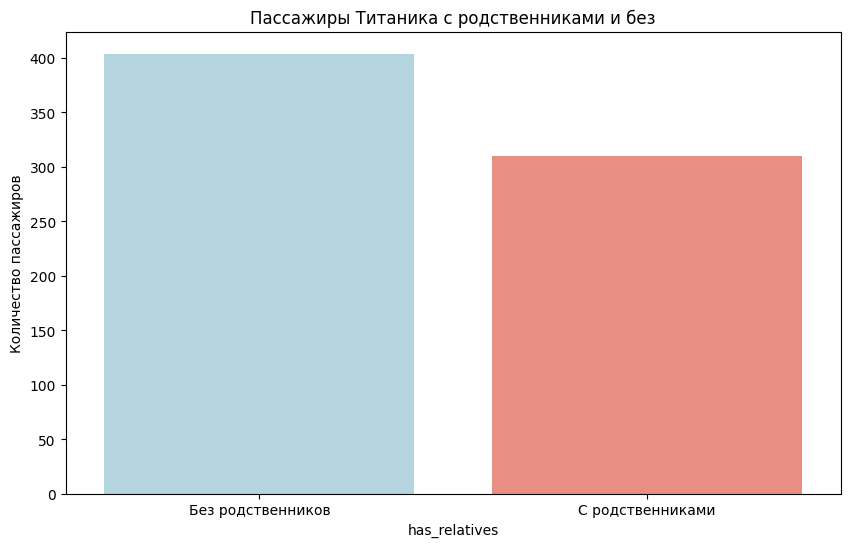

In [8]:
df['has_relatives'] = (df['Parch'] > 0) | (df['SibSp'] > 0)
relatives_counts = df['has_relatives'].value_counts()
labels = ['Без родственников', 'С родственниками']
plt.figure(figsize=(10, 6))
sns.barplot(x=relatives_counts.index, y=relatives_counts.values,
            palette=['lightblue', 'salmon'])
plt.title('Пассажиры Титаника с родственниками и без')
plt.ylabel('Количество пассажиров')
plt.xticks([0, 1], labels)



# 3. Построить график типа boxplot для столбца Age

3) Строим boxplot для возрастов пассажиров. `Сначала sns.boxplot(data=df, y='Age', color='pink')` показывает 5 ключевых статистик - медиану, нижний край ящика, усы - типичный диапазон без выбросов и точки-выбросы, а `figsize=(20,20)`, увеличенные шрифты.


Text(0, 0.5, 'Возраст')

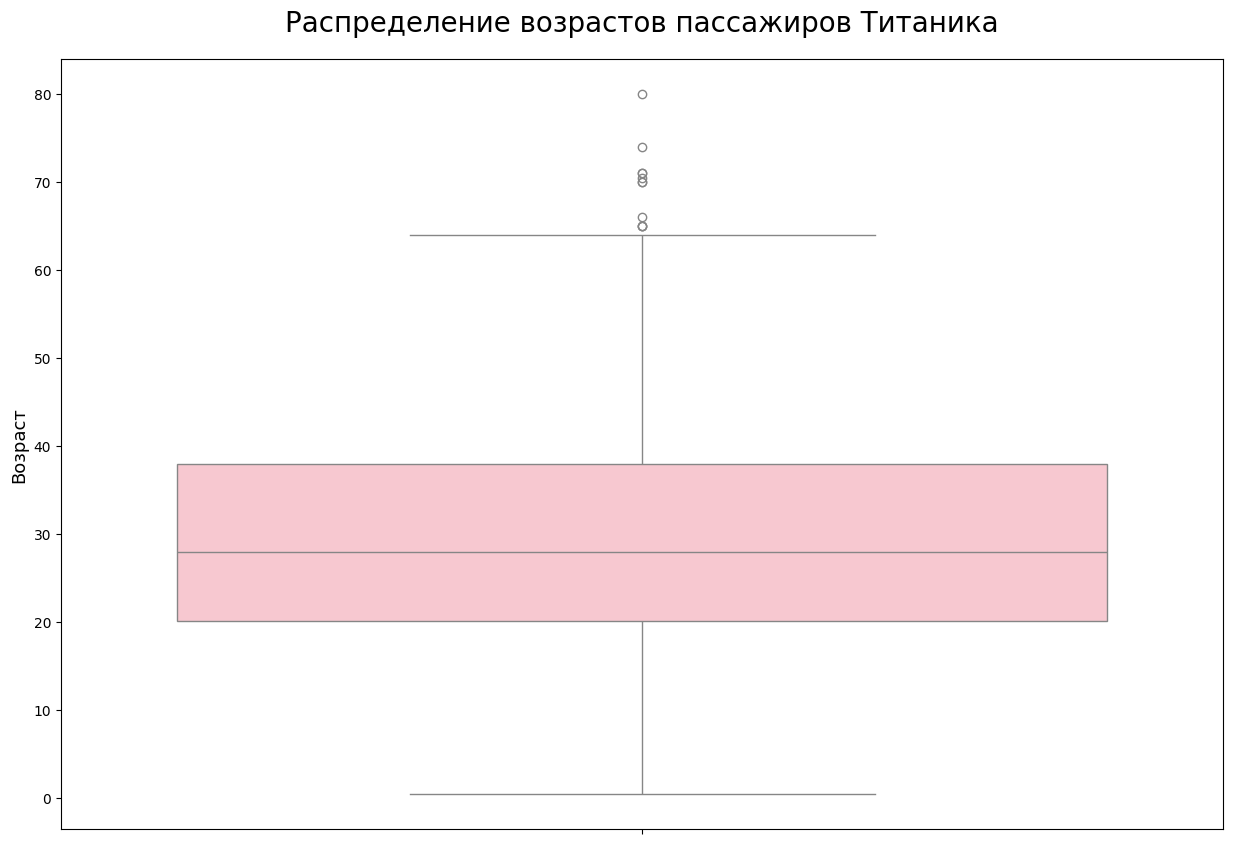

In [9]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df, y='Age', color='pink')
plt.title('Распределение возрастов пассажиров Титаника', fontsize=20, pad=20)
plt.ylabel('Возраст', fontsize=13)



# 4. Проинтерпретировать полученный график

4) Выведем основную инфу полученную из боксплота. Медиана, границы ящика, минимальный и максимальный возраст.

In [10]:

print(f" Медиана: {df['Age'].median():.1f}")
print(f" 25% младше {df['Age'].quantile(0.25):.1f}")
print(f" 75% младше {df['Age'].quantile(0.75):.1f}")
print(f" Основная масса: {df['Age'].quantile(0.25):.1f}-{df['Age'].quantile(0.75):.1f}")
print(" Минимальный возраст:", df['Age'].min())
print(" Максимальный:", df['Age'].max())

 Медиана: 28.0
 25% младше 20.1
 75% младше 38.0
 Основная масса: 20.1-38.0
 Минимальный возраст: 0.42
 Максимальный: 80.0


# 5. Построить график типа pie chart для переменных Survived, Pclass, подписать доли в процентах

С помощью p`lt.pie(x=data.values, labels=['3 класс', '1 класс', '2 класс']`,
А с помощью `autopct='%1.1f%%'` отображаем проценты. Также добавляем белую линию для разделения.

1. Распределение по выживаемостью

Text(0.5, 1.0, 'Распределение по выживаемости')

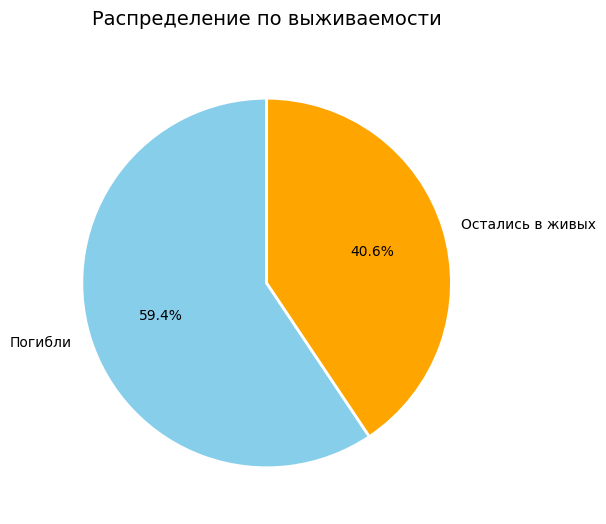

In [11]:
data = df['Survived'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(x=data.values, labels=['Погибли', 'Остались в живых'],
        colors=['skyblue', 'orange'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'linewidth': 2, 'edgecolor': 'white'})
plt.title('Распределение по выживаемости', fontsize=14, pad=20)



2. Распределение по классам

Text(0.5, 1.0, 'Распределение по классам')

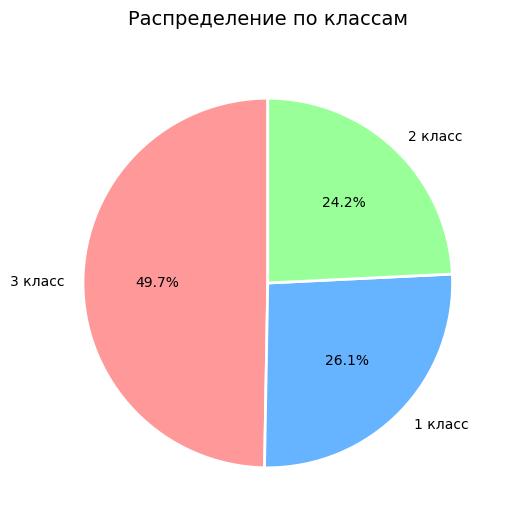

In [12]:
data = df['Pclass'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(x=data.values, labels=['3 класс', '1 класс', '2 класс'],
        colors=['#ff9999', '#66b3ff', '#99ff99'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'linewidth': 2, 'edgecolor': 'white'})
plt.title('Распределение по классам', fontsize=14, pad=20)



# 6. Построить график типа pairplot для всех числовых переменных датасета

Сначала `select_dtypes()` отбирает столбцы в которых только числовые значения. Потом `sns.pairplot()` сстроятся графики зависимостей величин друг от друга, а по диагонали отображаются графики плотности.

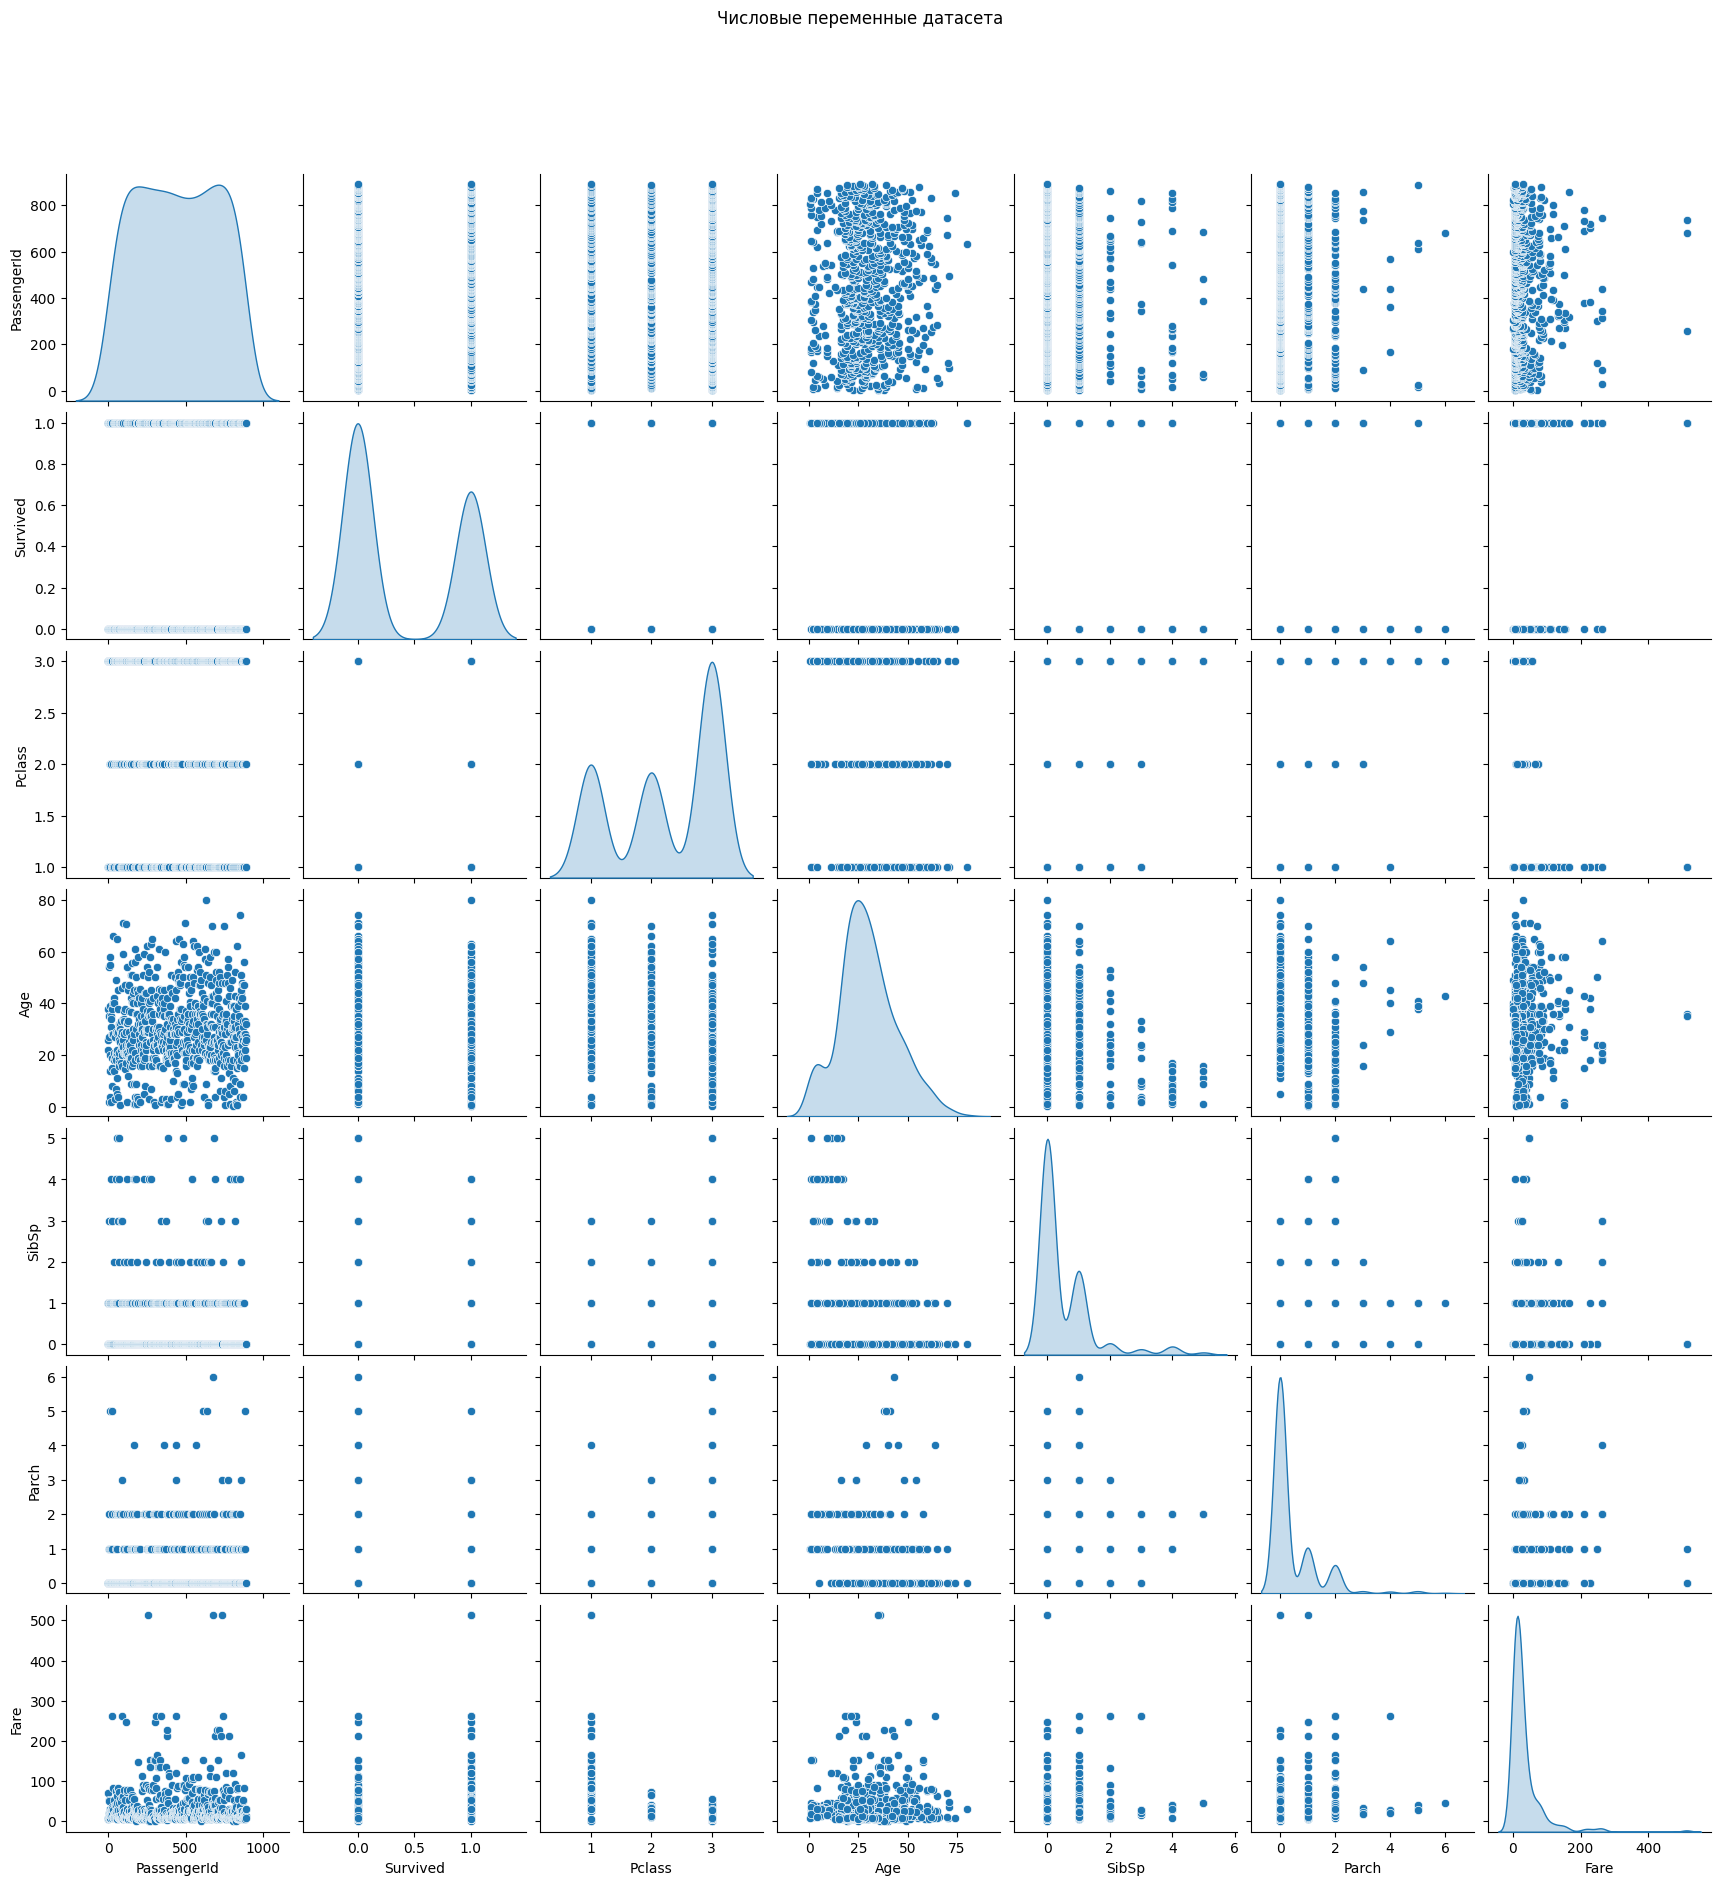

In [13]:
numeric_columns = df.select_dtypes(include=['int64','float64'])
sns.pairplot(numeric_columns, diag_kind="kde")
plt.suptitle("Числовые переменные датасета", y=1.08)
plt.show()

# 7. Построить violin plot распределения возраста (Age) в зависимости от пола (Sex)

Первой строчкой сразу меняем male и female на православные жензина и мужчина с помощью функции `map`. С помощью `sns.violinplot()` строится распределение с указанием необходимых осей.

Text(0, 0.5, 'Возраст')

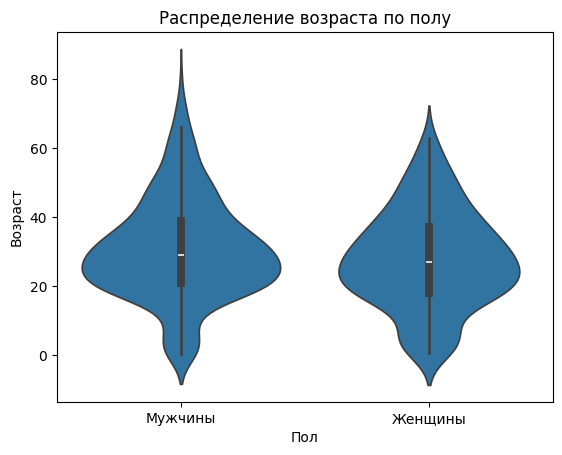

In [17]:
df['Sex_ru'] = df['Sex'].map({'male': 'Мужчины', 'female': 'Женщины'})
sns.violinplot(x='Sex_ru', y='Age', data=df)
plt.title('Распределение возраста по полу')
plt.xlabel('Пол')
plt.ylabel('Возраст')



# 8. Построить heatmap корреляционной матрицы числовых признаков

`num_df = df.select_dtypes(include=['int64','float64'])` отбирает столбцы с числами,` .corr()` вычисляет коэффициенты корреляции от -1 до +1 между всеми парами переменных, а `sns.heatmap` визуализирует матрицу

Text(0.5, 1.0, 'heatmap кореляционной матрицы')

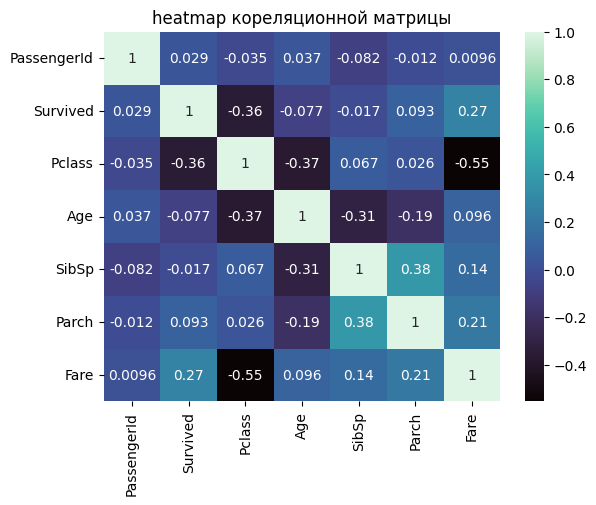

In [15]:
num_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(num_df.corr(), annot=True, cmap='mako')
plt.title('heatmap кореляционной матрицы')


# 9
Построить интерактивный sunburst plot (plotly):

первый уровень — количество пассажиров в каждом классе,
второй уровень — количество женщин/мужчин в каждом классе

Функция `sunburst() ` из специальной библиотеки строит интерактивный suburst plot, далее с помощью `path` задаем уровни.





In [19]:
fig = px.sunburst(df, path=['Pclass', 'Sex'],title='Распределение по классу и полу одновременно')

fig.show()